Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.


In [1]:
#Importing library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading dataset
df=pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

In [3]:
#Understanding the data
#Top 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
#Last 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [6]:
#Dataset shape
#Dataset tolist
#Dataset types
df.shape


(4000, 28)

In [8]:
df.columns.tolist()


['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [9]:
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [12]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [15]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [18]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().sum() / len(df) * 100
    ).round(2)
})


In [19]:
#Handling Missing Values
numeric_columns = df.select_dtypes(
    include=np.number
).columns

# Categorical columns
categorical_columns = df.select_dtypes(
    exclude=np.number
).columns

# Fill numerical missing values with median
for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Remove duplicate records
df = df.drop_duplicates()

print("Missing values after treatment:",
      df.isnull().sum().sum())

print("Duplicate records after treatment:",
      df.duplicated().sum())

Missing values after treatment: 0
Duplicate records after treatment: 0


In [20]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


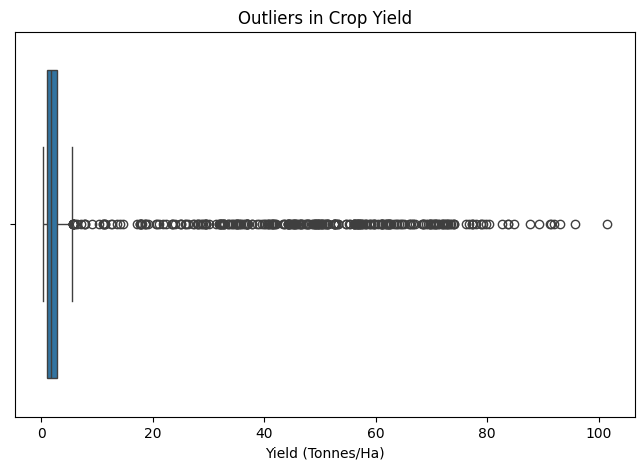

In [21]:
# Check for outliers in Yield

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Yield_Tonnes_Ha'])

plt.title('Outliers in Crop Yield')
plt.xlabel('Yield (Tonnes/Ha)')

plt.show()

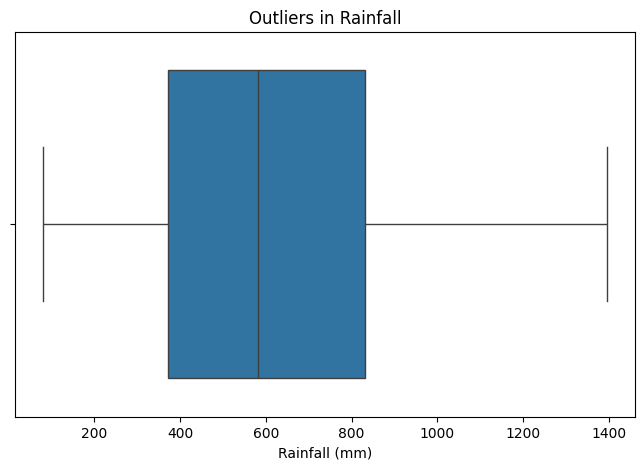

In [22]:
# Check for outliers in Rainfall

plt.figure(figsize=(8,5))

sns.boxplot(x=df['Rainfall_mm'])

plt.title('Outliers in Rainfall')
plt.xlabel('Rainfall (mm)')

plt.show()

### Outlier Analysis

Boxplots were used to identify possible outliers in important
variables such as yield, profit and rainfall. Some extreme values
were observed. These values were not removed automatically because
they may represent genuine differences in agricultural conditions.

In [24]:
# Descriptive statistics
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [29]:
Average_Yield=df['Yield_Tonnes_Ha'].mean()
print('Average Yield:',Average_Yield)

print("Average Production:", df['Production_Tonnes'].mean())

print("Average Profit:", df['Profit_INR'].mean())

print("Average Water Used:", df['Water_Used_m3'].mean())

Average Yield: 5.242349999999999
Average Production: 43.246210000000005
Average Profit: 111556.465
Average Water Used: 6045.57025


### Interpretation

The descriptive statistics show the average, minimum, maximum,
and spread of the numerical variables in the agricultural dataset.

In [30]:
# Number of records in each season

df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


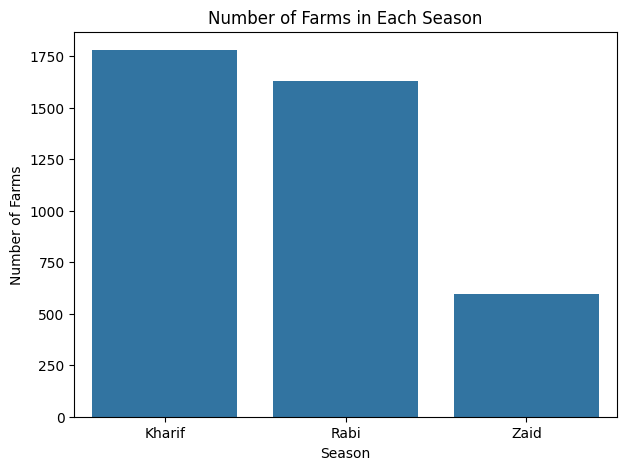

In [31]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Season')

plt.title('Number of Farms in Each Season')
plt.xlabel('Season')
plt.ylabel('Number of Farms')

plt.show()

In [32]:
# Number of records for each crop

df['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


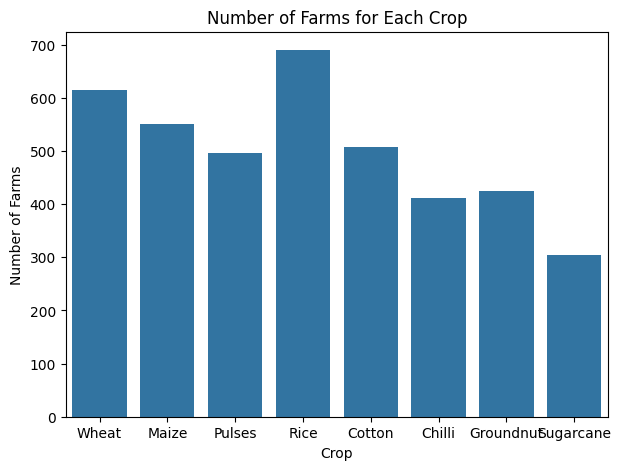

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='Crop')

plt.title('Number of Farms for Each Crop')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')

plt.show()

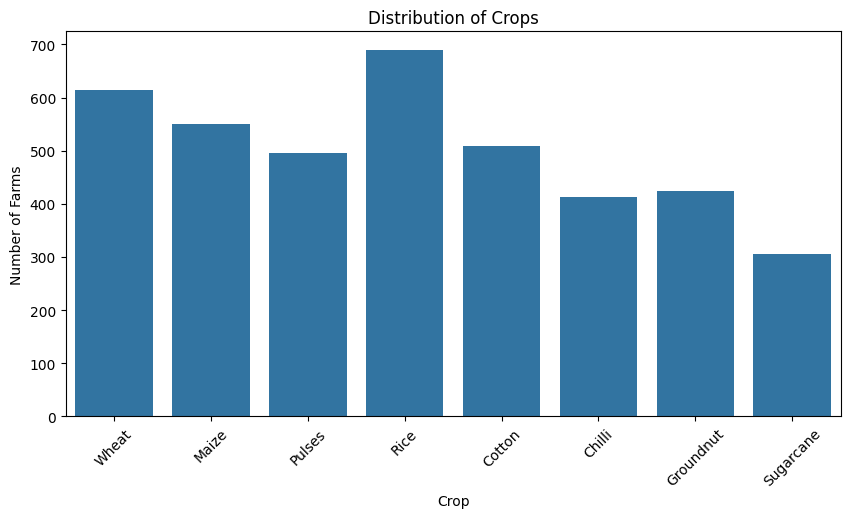

In [34]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x='Crop'
)

plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')

plt.xticks(rotation=45)

plt.show()

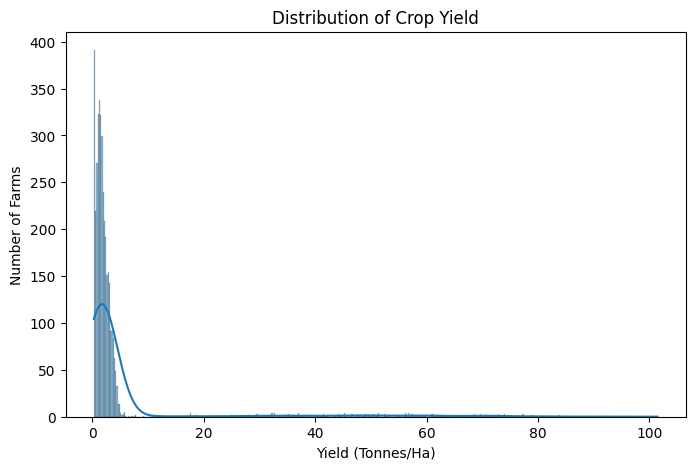

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(df['Yield_Tonnes_Ha'],kde=True)
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Number of Farms')

plt.show()

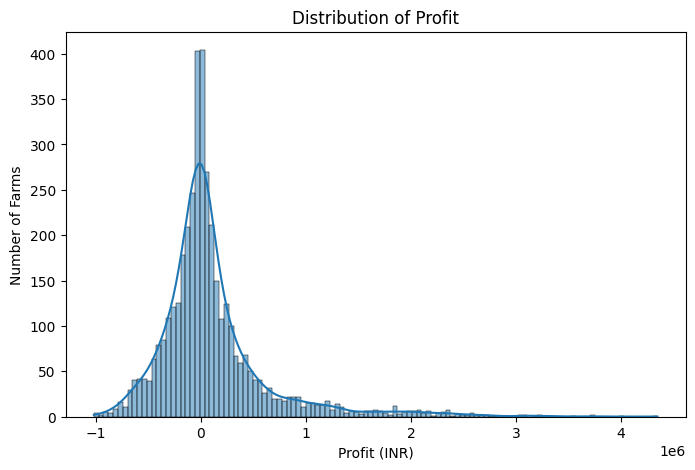

In [37]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Profit_INR'],
    kde=True
)

plt.title('Distribution of Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Number of Farms')

plt.show()

### Univariate Analysis

The distribution of seasons and crops was examined to understand
the composition of the dataset. Histograms were also used to
understand the distribution of yield and profit.

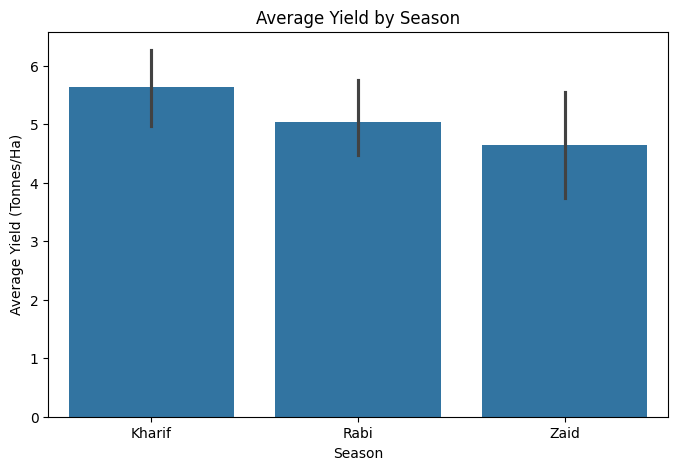

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

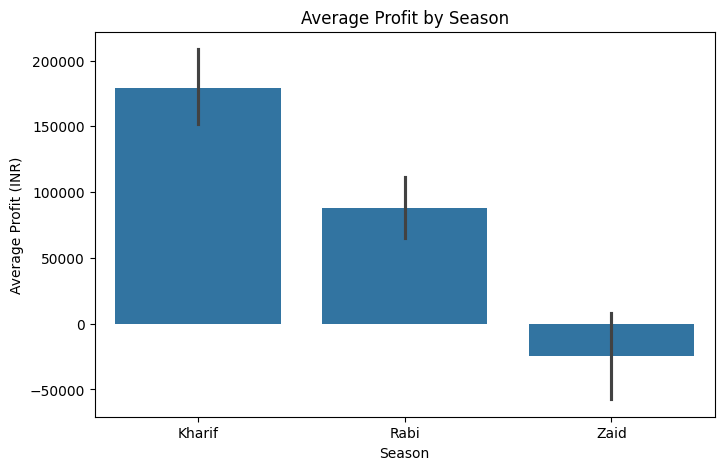

In [42]:
#Season VS profit
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

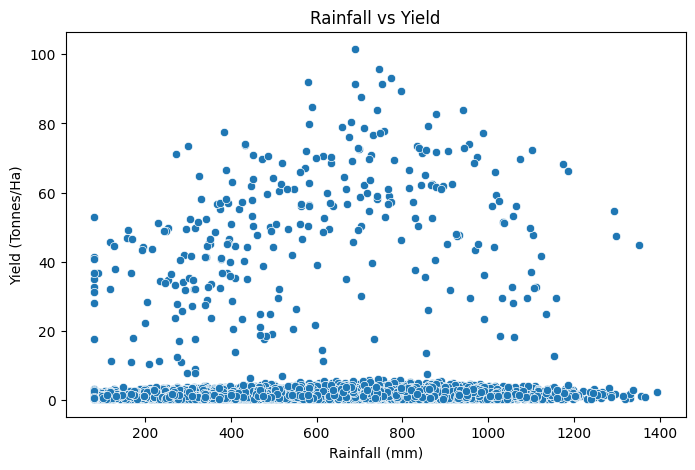

In [43]:
#Rainfall VS Yield
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha'
)

plt.title('Rainfall vs Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

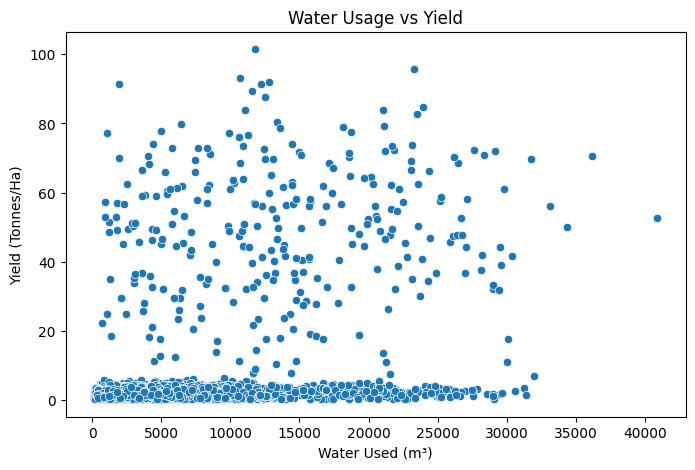

In [44]:
#Water usage VS Yield
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Water_Used_m3',
    y='Yield_Tonnes_Ha'
)

plt.title('Water Usage vs Yield')
plt.xlabel('Water Used (m³)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [45]:
# Average yield for each crop in each season

crop_season = df.groupby(
    ['Crop', 'Season']
)['Yield_Tonnes_Ha'].mean()

crop_season

Crop       Season
Chilli     Kharif     1.731459
           Rabi       1.465031
           Zaid       1.195312
Cotton     Kharif     1.374512
           Rabi       1.198358
           Zaid       0.960217
Groundnut  Kharif     1.484974
           Rabi       1.233164
           Zaid       1.037778
Maize      Kharif     2.966410
           Rabi       2.603648
           Zaid       2.290952
Pulses     Kharif     1.036063
           Rabi       0.875962
           Zaid       0.669677
Rice       Kharif     2.698376
           Rabi       2.322847
           Zaid       1.900490
Sugarcane  Kharif    53.459120
           Rabi      43.286124
           Zaid      38.423922
Wheat      Kharif     2.253664
           Rabi       2.057468
           Zaid       1.748588
Name: Yield_Tonnes_Ha, dtype: float64

<Axes: xlabel='Crop', ylabel='Yield_Tonnes_Ha'>

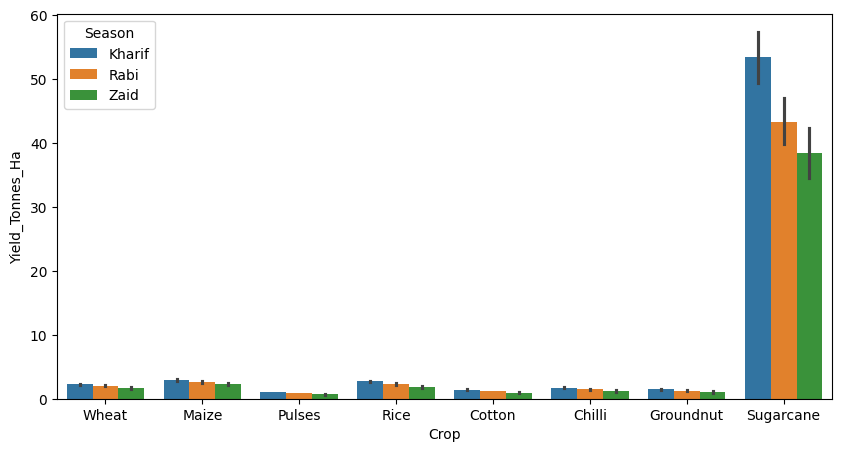

In [46]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=df,
    x='Crop',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

### Correlation Analysis

Correlation analysis was used to understand the relationships
between agricultural, environmental, resource and performance
variables.

A positive correlation indicates that two variables tend to increase
together, while a negative correlation indicates an opposite
relationship. Correlation does not prove causation.

In [51]:
crop_yield = df.groupby(
    ['Season', 'Crop']
)['Yield_Tonnes_Ha'].mean().reset_index()

crop_yield

,Season,Crop,Yield_Tonnes_Ha
0,Kharif,Chilli,1.731459
1,Kharif,Cotton,1.374512
2,Kharif,Groundnut,1.484974
3,Kharif,Maize,2.966410
4,Kharif,Pulses,1.036063
5,Kharif,Rice,2.698376
6,Kharif,Sugarcane,53.459120
7,Kharif,Wheat,2.253664
8,Rabi,Chilli,1.465031
9,Rabi,Cotton,1.198358


In [52]:
crop_yield.sort_values(
    'Yield_Tonnes_Ha',
    ascending=False)

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.286124
22,Zaid,Sugarcane,38.423922
3,Kharif,Maize,2.966410
5,Kharif,Rice,2.698376
11,Rabi,Maize,2.603648
13,Rabi,Rice,2.322847
19,Zaid,Maize,2.290952
7,Kharif,Wheat,2.253664
15,Rabi,Wheat,2.057468


In [55]:
state_yield = df.groupby(
    ['Season', 'State']
)['Yield_Tonnes_Ha'].mean().reset_index()

state_yield.sort_values(
    'Yield_Tonnes_Ha',
    ascending=False
)

,Season,State,Yield_Tonnes_Ha
13,Rabi,Punjab,8.609355
18,Zaid,Karnataka,6.623243
2,Kharif,Karnataka,6.455024
1,Kharif,Gujarat,6.338416
3,Kharif,Madhya Pradesh,5.985265
21,Zaid,Punjab,5.909610
0,Kharif,Andhra Pradesh,5.676958
7,Kharif,Telangana,5.552436
6,Kharif,Tamil Nadu,5.520534
12,Rabi,Maharashtra,5.501927


In [56]:
for season in df['Season'].unique():

    print("\nSeason:", season)

    temp = state_yield[
        state_yield['Season'] == season
    ]

    print(
        temp.sort_values(
            'Yield_Tonnes_Ha',
            ascending=False
        ).head(3)
    )


Season: Kharif
   Season           State  Yield_Tonnes_Ha
2  Kharif       Karnataka         6.455024
1  Kharif         Gujarat         6.338416
3  Kharif  Madhya Pradesh         5.985265

Season: Rabi
   Season        State  Yield_Tonnes_Ha
13   Rabi       Punjab         8.609355
12   Rabi  Maharashtra         5.501927
9    Rabi      Gujarat         5.441700

Season: Zaid
   Season           State  Yield_Tonnes_Ha
18   Zaid       Karnataka         6.623243
21   Zaid          Punjab         5.909610
19   Zaid  Madhya Pradesh         5.478889


In [58]:
#Final Result

print("Average Yield by Season")
print(
    df.groupby('Season')['Yield_Tonnes_Ha'].mean()
)

print("\nAverage Profit by Season")
print(
    df.groupby('Season')['Profit_INR'].mean()
)

print("\nAverage Water Usage by Season")
print(
    df.groupby('Season')['Water_Used_m3'].mean()
)

print("\nAverage Rainfall by Season")
print(
    df.groupby('Season')['Rainfall_mm'].mean()
)

print("\nAverage Production by Season")
print(
    df.groupby('Season')['Production_Tonnes'].mean()
)

print("\nAverage Fertilizer Usage by Season")
print(
    df.groupby('Season')['Fertilizer_kg_ha'].mean()
)

Average Yield by Season
Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64

Average Profit by Season
Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

Average Water Usage by Season
Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64

Average Rainfall by Season
Season
Kharif    849.199663
Rabi      437.615366
Zaid      304.654714
Name: Rainfall_mm, dtype: float64

Average Production by Season
Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64

Average Fertilizer Usage by Season
Season
Kharif    187.077965
Rabi      185.407068
Zaid      184.638047
Name: Fertilizer_kg_ha, dtype: float64


In [60]:
season_result = df.groupby('Season')[
    [
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Profit_INR'
    ]
].mean()

print(season_result.round(2))

        Yield_Tonnes_Ha  Production_Tonnes  Profit_INR
Season                                                
Kharif             5.63              46.31   178914.65
Rabi               5.04              41.49    87689.47
Zaid               4.64              38.89   -24804.82


### Insight 1

Kharif recorded the highest average yield among the three seasons.

### Interpretation

This shows that agricultural yield varies across seasons in the
dataset. The variation may be associated with differences in
environmental conditions, farming practices and resource usage.

## Recommendations

1. Seasonal crop planning can be improved by considering the
   differences in crop yield across seasons.

2. Water usage should be monitored along with yield to identify
   opportunities for better water management.

3. Fertilizer and pesticide usage should be evaluated according
   to crop and seasonal requirements.

4. States showing better performance in particular seasons can
   be studied to understand their agricultural practices.

5. Environmental conditions such as rainfall, temperature and
   soil moisture should be considered when planning seasonal
   farming activities.

6. Profit should be considered along with yield when evaluating
   agricultural performance.

7. Resources should be allocated according to the requirements
   of different crops and seasons.

8. Further investigation can be carried out for unusual yield,
   rainfall or profit values identified during the analysis.

## Limitations

- The analysis is based only on the variables available in the
  provided dataset.

- The dataset may not represent all agricultural regions and
  farming conditions.

- Correlation shows relationships but does not prove causation.

- Missing values were handled during the data-cleaning process.

- Some extreme values may represent genuine agricultural
  conditions.

- Other factors such as weather events, farmer experience,
  crop variety and market conditions may also affect agricultural
  performance.

Conclusion

The project analyzed agricultural performance across different
seasons using data analytics techniques.

The analysis included data cleaning, descriptive statistics,
univariate analysis, bivariate analysis, multivariate analysis,
correlation analysis and seasonal comparisons.

The study examined differences in crop yield, production, resource
usage, environmental conditions and economic performance.

Crop-wise and state-wise analyses were also performed to identify
additional seasonal patterns.

The findings provide useful information about seasonal differences
in agricultural performance and can support better crop planning,
resource management and agricultural decision-making.